<a href="https://colab.research.google.com/github/jahnavitelsang/DATASCIENCE/blob/main/KMEANS_AND_DBSCAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/shopping_data.csv')

In [ ]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [ ]:
df.shape

(200, 5)

In [ ]:
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
df = df.iloc[:,2:]
df.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


In [ ]:
from sklearn.cluster import KMeans

In [ ]:
kmeans = KMeans(n_clusters=5,random_state=42)
kmeans.fit(df)

KMeans(n_clusters=5, random_state=42)

In [ ]:
y = kmeans.predict(df)
y

array([2, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2,
       0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2,
       0, 2, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 2,
       0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4, 0, 0, 0, 0, 0, 0,
       0, 4, 0, 0, 0, 4, 0, 0, 0, 0, 4, 0, 4, 4, 3, 4, 3, 4, 3, 4, 3, 4,
       3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4,
       3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4,
       3, 4, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1], dtype=int32)

In [ ]:
y = pd.DataFrame(y)
y

,0
0,2
1,2
2,0
3,2
4,0
...,...
195,1
196,3
197,1
198,3


In [ ]:
#finding centers

In [ ]:
c = kmeans.cluster_centers_
c

array([[ 46.21348315,  47.71910112,  41.79775281],
       [ 32.45454545, 108.18181818,  82.72727273],
       [ 24.68965517,  29.5862069 ,  73.65517241],
       [ 40.39473684,  87.        ,  18.63157895],
       [ 31.78787879,  76.09090909,  77.75757576]])

In [ ]:
#now lets create a empty list to create wcss and plotting the elbow plot

In [ ]:
#n_clusters=i: In each iteration, the algorithm attempts to group the data into i clusters.

#n_init=20: This tells the algorithm to run the K-Means process 20 times with different random centroid seeds and choose the best result (the one with the lowest inertia) as the final model for that iteration. This helps avoid getting stuck in suboptimal local minima.

#kmeans.fit(df): This calculates the optimal centroids for the specified number of clusters based on your data (df).
inertia = []
for i in range(1,11):
  kmeans = KMeans(n_clusters=i,random_state=42,n_init=20)
  kmeans.fit(df)
  inertia.append(kmeans.inertia_)

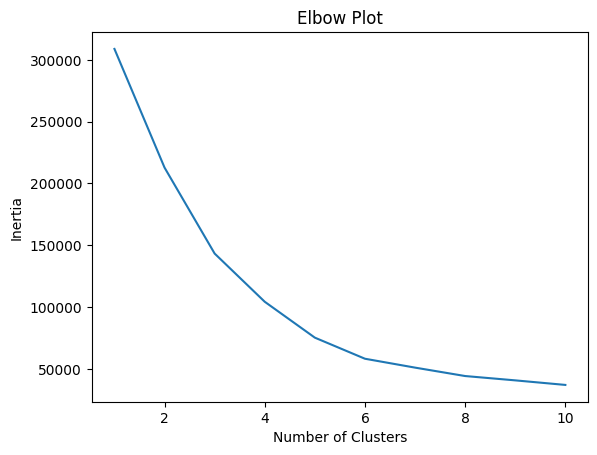

In [ ]:
plt.plot(range(1,11),inertia)
plt.title('Elbow Plot')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()

In [ ]:
#DBSCAN

In [ ]:

df_model = df.drop('CustomerID',axis=1)

In [ ]:
#encode
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df_model['Genre'] = le.fit_transform(df_model['Genre'])
df_model.head()

,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40


In [ ]:
x = df_model
#Apply standard scalar
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
x_scaled = ss.fit_transform(x_scaled)
x_scaled = pd.DataFrame(x_scaled)
x_scaled.columns = ['Genre','Age','Annual Income (k$)','Spending Score (1-100)']

x_scaled.head()


,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1.128152,-1.424569,-1.738999,-0.434801
1,1.128152,-1.281035,-1.738999,1.195704
2,-0.886405,-1.352802,-1.700830,-1.715913
3,-0.886405,-1.137502,-1.700830,1.040418
4,-0.886405,-0.563369,-1.662660,-0.395980


In [ ]:
from sklearn.cluster import DBSCAN
dbs = DBSCAN(eps=0.8,min_samples=5)
labels = dbs.fit_predict(x_scaled)

In [ ]:
df_model['Cluster'] = labels


In [ ]:
print(df_model['Cluster'].value_counts())


Cluster
 1    94
 2    40
 3    26
-1    19
 4    12
 0     9
Name: count, dtype: int64


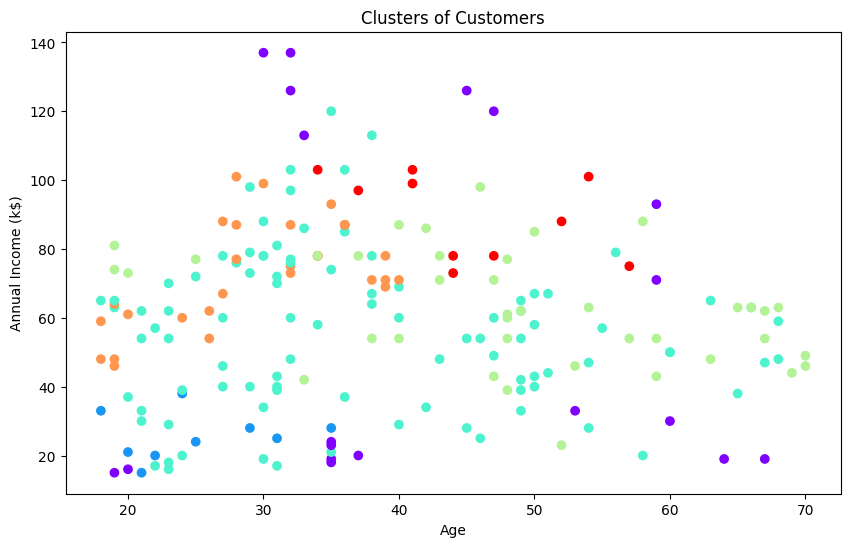

In [ ]:
#visulaization of 2 features: nage vs income
plt.figure(figsize=(10,6))
plt.scatter(df_model['Age'],df_model['Annual Income (k$)'],c=df_model['Cluster'],cmap='rainbow')
plt.xlabel('Age')
plt.ylabel('Annual Income (k$)')
plt.title('Clusters of Customers')
plt.show()